# Implementación de la librería Geopandas

Descripción:
    En este notebook se realizó un ejemplo de uso de la librería geopandas

## Importación de librerías

- Pandas: especializada en el manejo y analisís de estructuras de datos.
- Geopandas: especializada en el manejo de datos geoespaciales.
- Matplotlib: especializada en el manejo fundamental de visualización de datos.
- Contextily: especializada en el manejo de mapas base.

In [1]:
#Install contextily and geopandas
!pip install contextily --upgrade
!pip install geopandas

import pandas as pd #Import pandas
import geopandas as gpd #Import geopandas
import matplotlib.pyplot as plt #Import matplotlib
import contextily as ctx #Import contextily

## Cargar archivo en formato CSV (dataset)

In [2]:
urlgithub = "https://raw.githubusercontent.com/gmmorales/datasets/refs/heads/delitos/delitos_2021_caba.csv" # url github dataset
df = pd.read_csv(urlgithub)

## Exploración general del conjunto de datos

### Tamaño y tipo de datos (Shape and Types)

In [3]:
print("Filas y columnas:\n") #show rows and columns
df.shape

Filas y columnas:



(85901, 15)

In [4]:
#Show datatype
print("\nTipos de Dato\n")
print(df.dtypes)


Tipos de Dato

id_delito             object
fecha                 object
franja_horaria         int64
tipo                  object
subtipo               object
uso_armas             object
t_respuesta (min)      int64
arresto               object
Id_arresto            object
Id_oficial             int64
barrio                object
comuna                 int64
latitud              float64
longitud             float64
victimas               int64
dtype: object


### Nombres de las columnas o encabezados y registros

In [5]:
df.head(0) #show headers names

,id_delito,fecha,franja_horaria,tipo,subtipo,uso_armas,t_respuesta (min),arresto,Id_arresto,Id_oficial,barrio,comuna,latitud,longitud,victimas


In [6]:
df.head(3) #Show headers names and records

,id_delito,fecha,franja_horaria,tipo,subtipo,uso_armas,t_respuesta (min),arresto,Id_arresto,Id_oficial,barrio,comuna,latitud,longitud,victimas
0,DEL1000647041,1/1/2021,0,Lesiones,Siniestro Vial,NaN,47,si,ARR0217701,1100493,Villa Lugano,8,-34.672422,-58.493447,0
1,DEL1000647043,1/1/2021,10,Lesiones,Siniestro Vial,NaN,112,no,NaN,1100460,San Telmo,1,-34.621941,-58.374171,1
2,DEL1000647044,1/1/2021,6,Lesiones,Siniestro Vial,NaN,144,no,NaN,1100174,Boca,4,-34.637012,-58.366628,1


In [7]:
df.tail() #Show the last records

,id_delito,fecha,franja_horaria,tipo,subtipo,uso_armas,t_respuesta (min),arresto,Id_arresto,Id_oficial,barrio,comuna,latitud,longitud,victimas
85896,DEL1000735603,12/31/2021,19,Robo (con violencia),NaN,NaN,92,no,NaN,1100368,San Telmo,1,-34.618627,-58.376624,0
85897,DEL1000735604,12/31/2021,2,Hurto (sin violencia),NaN,NaN,101,no,NaN,1100006,Recoleta,2,-34.597475,-58.389054,0
85898,DEL1000735605,12/31/2021,12,Robo (con violencia),NaN,NaN,157,si,ARR0260180,1100099,Colegiales,13,-34.574402,-58.449388,0
85899,DEL1000735606,12/31/2021,19,Hurto (sin violencia),NaN,NaN,93,si,ARR0260181,1100113,Villa Del Parque,11,-34.610161,-58.490887,0
85900,DEL1000735607,12/31/2021,10,Robo (con violencia),NaN,NaN,99,no,NaN,1100363,Palermo,14,-34.591937,-58.414820,0


## Distribución geográfica de los delitos ocurridos

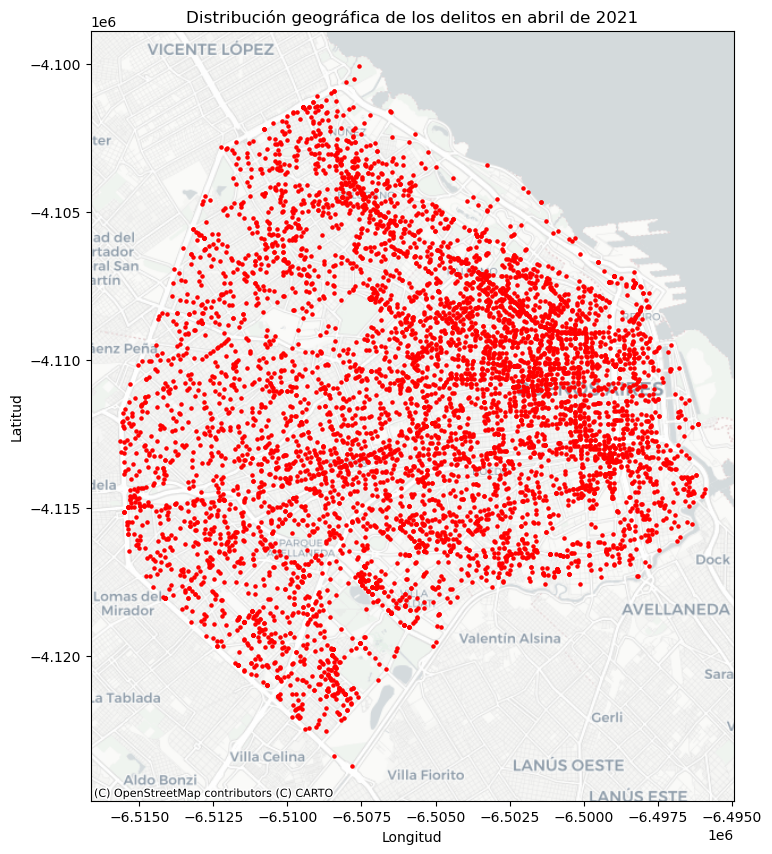

In [8]:
#Delete rows with null values ​​in 'latitude' and 'longitude' columns
df = df.dropna(subset=['latitud', 'longitud'])

#Convert 'date' to datetime
df['fecha'] = pd.to_datetime(df['fecha'])

#Filter data for April 2021
df_abril_2021 = df[(df['fecha'].dt.year == 2021) & (df['fecha'].dt.month == 4)]

#Convert to a GeoDataFrame
gdf_abril_2021 = gpd.GeoDataFrame(df_abril_2021, geometry=gpd.points_from_xy(df_abril_2021['longitud'], df_abril_2021['latitud']))

#Assign the EPSG:4326 coordinate system
gdf_abril_2021.crs = "EPSG:4326"

#Convert to EPSG:3857 to add a background map
gdf_abril_2021 = gdf_abril_2021.to_crs(epsg=3857)

#Create the chart
fig, ax = plt.subplots(figsize=(10, 10))
gdf_abril_2021.plot(ax=ax, marker='o', color='red', markersize=5)

#Add background map
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

#Show plot
plt.title("Distribución geográfica de los delitos en abril de 2021")
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()